In [147]:
import pypsa
import pandas as pd
import numpy as np
import xarray as xr

import matplotlib.pyplot as plt
import seaborn as sns
import re

### Paths

In [148]:
trade_model = "../../results/cost_year~2030/transport_cost~steel_r_iron_r/demand~1/product~steel/network.nc"
single_region = "../../resources/lcos/cost_year~2030/South_South_America/network_1.nc"

### Read trade model

In [149]:
n = pypsa.Network(trade_model)

INFO:pypsa.network.io:New version 1.0.4 available! (Current: 0.35.0)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, links, loads


In [150]:
n_ssa = pypsa.Network(single_region)

INFO:pypsa.network.io:New version 1.0.4 available! (Current: 0.35.0)
INFO:pypsa.network.io:Imported network 'steel shipping' has buses, carriers, generators, links, loads, stores


In [151]:
n_ssa.statistics()

Optimal Capacity  \
Generator -                                     2254.21561   
          Photovoltaics                          687.36858   
          Wind energy                          12034.92606   
Link      Steel                                 1309.26337   
          battery inverter (charging)              0.00000   
          battery inverter (discharging)           0.00000   
          direct reduction furnace              2254.21561   
          electric arc furnace                  1309.26337   
          electrolysis                          5075.01932   
Load      Steel                                    0.00000   
Store     Battery                                  0.00000   
          HBI                                 511760.73246   
          Steel                               685295.22579   

                                          Installed Capacity        Supply  \
Generator -                                              0.0  1.823684e+07   
          Photovoltaics                                  0.0  1.176197e+06   
          Wind energy                                    0.0  5.902876e+07   
Link      Steel                                          0.0  0.000000e+00   
          battery inverter (charging)                    0.0  0.000000e+00   
          battery inverter (discharging)                 0.0  0.000000e+00   
          direct reduction furnace                       0.0  0.000000e+00   
          electric arc furnace                           0.0  0.000000e+00   
          electrolysis                                   0.0  0.000000e+00   
Load      Steel                                          0.0  0.000000e+00   
Store     Battery                                        0.0  0.000000e+00   
          HBI                                            0.0  6.274760e+05   
          Steel                                          0.0  0.000000e+00   

                                            Withdrawal  Energy Balance  \
Generator -                               0.000000e+00    1.823684e+07   
          Photovoltaics                   0.000000e+00    1.176197e+06   
          Wind energy                     0.000000e+00    5.902876e+07   
Link      Steel                           1.146915e+07   -1.146915e+07   
          battery inverter (charging)     2.000000e-05   -2.000000e-05   
          battery inverter (discharging)  2.000000e-05   -2.000000e-05   
          direct reduction furnace        1.823684e+07   -1.823684e+07   
          electric arc furnace            1.146915e+07   -1.146915e+07   
          electrolysis                    4.105743e+07   -4.105743e+07   
Load      Steel                           1.146915e+07   -1.146915e+07   
Store     Battery                         0.000000e+00    0.000000e+00   
          HBI                             6.274760e+05    0.000000e+00   
          Steel                           0.000000e+00    0.000000e+00   

                                          Transmission  Capacity Factor  \
Generator -                               0.000000e+00         0.923528   
          Photovoltaics                   0.000000e+00         0.195338   
          Wind energy                     0.000000e+00         0.559907   
Link      Steel                           1.146915e+07         1.000000   
          battery inverter (charging)     0.000000e+00         0.000000   
          battery inverter (discharging)  0.000000e+00         0.000000   
          direct reduction furnace        0.000000e+00         0.923528   
          electric arc furnace            0.000000e+00         1.000000   
          electrolysis                    0.000000e+00         0.923528   
Load      Steel                           0.000000e+00              NaN   
Store     Battery                         0.000000e+00         0.000000   
          HBI                             0.000000e+00         0.750851   
          Steel                           0.000000e+00         1.000

### Overview

In [153]:
n.statistics()

Optimal Capacity  Installed Capacity  \
Generator iron_ore               2.768647e+09                 0.0   
Link      shipping_iron_ore      1.933608e+09                 0.0   
          shipping_steel         1.307727e+09                 0.0   
          steel                  2.768647e+09                 0.0   
Load      -                      0.000000e+00                 0.0   

                                   Supply    Withdrawal  Energy Balance  \
Generator iron_ore           2.768647e+09  0.000000e+00    2.768647e+09   
Link      shipping_iron_ore  0.000000e+00  1.933608e+09   -1.933608e+09   
          shipping_steel     0.000000e+00  1.307727e+09   -1.307727e+09   
          steel              0.000000e+00  2.768647e+09   -2.768647e+09   
Load      -                  0.000000e+00  1.729761e+09   -1.729761e+09   

                             Transmission  Capacity Factor  Curtailment  \
Generator iron_ore           0.000000e+00              1.0          0.0   
Link      shipping_iron_ore  1.933608e+09              1.0          0.0   
          shipping_steel     1.307727e+09              1.0          0.0   
          steel              0.000000e+00              1.0          0.0   
Load      -                  0.000000e+00              NaN          0.0   

                             Capital Expenditure  Operational Expenditure  \
Generator iron_ore                  2.768647e+06             2.704968e+11   
Link      shipping_iron_ore         1.933608e+06             3.515336e+10   
          shipping_steel            1.307727e+06             4.171885e+10   
          steel                     2.768647e+06             8.155981e+11   
Load      -                         0.000000e+00             0.000000e+00   

                                  Revenue  Market Value  
Generator iron_ore           3.041823e+11    109.866768  
Link      shipping_iron_ore -2.100889e+11           NaN  
          shipping_steel    -8.651984e+11           NaN  
          steel             -3.393376e+11           NaN  
Load      -                 -1.221904e+12           NaN

### Iron ore supply costs (w/o transport)

In [154]:
iron_ore_cost = n.generators[n.generators.carrier == "iron_ore"].marginal_cost.mean()
iron_ore_to_steel = 1/n.links[n.links.carrier == 'steel'].efficiency.mean()
iron_ore_cost_notransport = iron_ore_cost * iron_ore_to_steel
print(f"Iron ore cost (w/o transport): {iron_ore_cost_notransport:.2f} €/t_steel")

Iron ore cost (w/o transport): 155.34 €/t_steel


Insight: iron ore costs are allocated in the transport model, as generator for each region. They are not included in the fundamental steel model, since iron ore trade is separate from steel modelling

### Steel supply costs

/tmp/ipykernel_3239/312114278.py:12: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



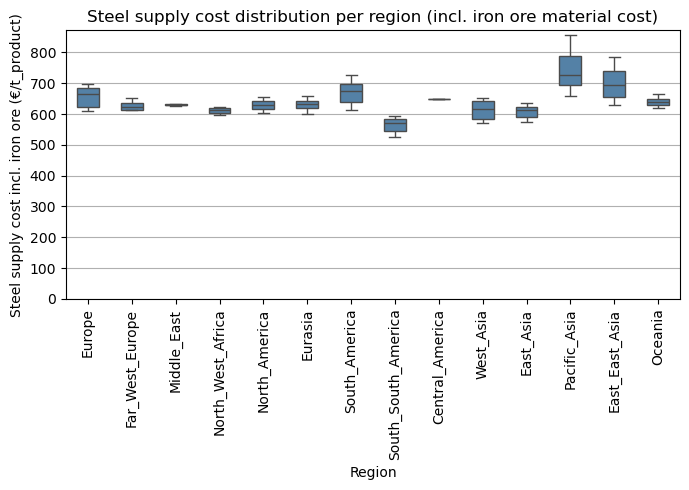

In [155]:
# Steel supply cost distribution per region (boxplot), including iron ore cost w/o transport
steel_links = n.links[n.links.carrier == 'steel'].copy()
steel_links['region'] = steel_links['bus1'].str.replace('_ore$', '', regex=True)
# Add iron ore cost w/o transport to each steel supply cost. The marginal cost of steel links refers to bus0, so an adjustment to steel (bus1) is required
steel_links['total_cost'] = steel_links['marginal_cost'] * iron_ore_to_steel + iron_ore_cost_notransport

fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(x='region', y='total_cost', data=steel_links, ax=ax, width=0.5, color='steelblue', fliersize=3)
ax.set_ylabel('Steel supply cost incl. iron ore (€/t_product)')
ax.set_xlabel('Region')
ax.set_title('Steel supply cost distribution per region (incl. iron ore material cost)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
ax.set_ylim(0, None)
ax.grid(axis='y')
plt.tight_layout()
plt.show()

### Steel supply costs single region

In [156]:
costs_per_carrier = n_ssa.statistics.system_cost() / n_ssa.statistics.energy_balance().loc["Load","Steel","Steel"]
costs_per_carrier #.sum()

component  carrier                       
Generator  Photovoltaics                    -2.294398e+00
           Wind energy                      -1.066583e+02
Link       battery inverter (charging)      -4.359522e-12
           battery inverter (discharging)   -4.359522e-12
           direct reduction furnace         -9.941485e+01
           electric arc furnace             -7.875192e+01
           electrolysis                     -8.350544e+01
Store      Battery                          -1.830999e-11
dtype: float64

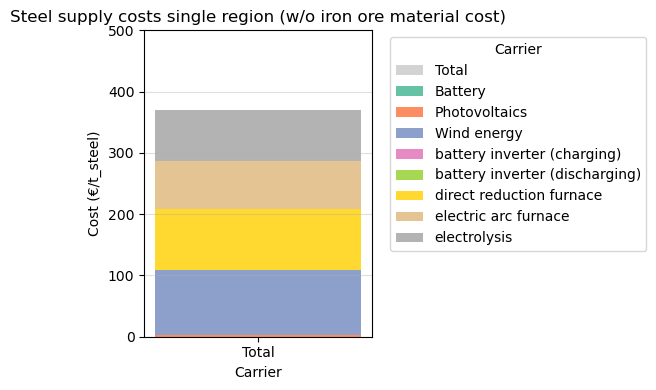

In [165]:
# Stacked bar chart of costs per carrier for single region
costs = costs_per_carrier.copy() * (-1)
costs = costs.groupby(level="carrier").sum()

fig, ax = plt.subplots(figsize=(6, 4))
colors = sns.color_palette('Set2', len(costs))
ax.bar(['Total'], [costs.sum()], color='lightgrey', label='Total')
bottom = 0
for i, (carrier, value) in enumerate(zip(costs.index, costs.values)):
    ax.bar(['Total'], [value], bottom=bottom, color=colors[i], label=carrier)
    bottom += value
ax.set_ylabel('Cost (€/t_steel)')
ax.set_xlabel('Carrier')
ax.set_title('Steel supply costs single region (w/o iron ore material cost)')
ax.grid(axis='y', alpha=0.4, zorder=0)
ax.legend(title='Carrier', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_ylim(0,500)
plt.tight_layout()
plt.show()

In [158]:
# Sanity check: objective value divided by total steel load should equal cost per ton steel
n_ssa.objective / n_ssa.statistics.energy_balance().loc["Load","Steel","Steel"] * (-1)

370.62488741001465

### Steel supply curve all regions

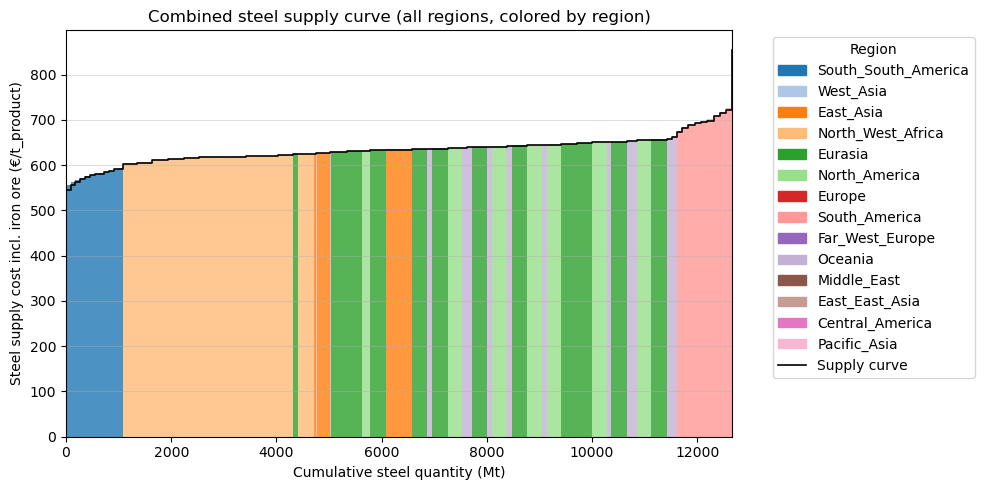

In [159]:
# Combined steel supply curve (all regions) as stacked area plot by region, sorted by cost
steel_links = n.links[n.links.carrier == 'steel'].copy()
steel_links['region'] = steel_links['bus1'].str.replace('_ore$', '', regex=True)
steel_links['total_cost'] = steel_links['marginal_cost'] * iron_ore_to_steel + iron_ore_cost_notransport
steel_links['quantity'] = steel_links['p_nom_max'] / 1e6  # Mt steel

# Sort by cost for supply curve
steel_links_sorted = steel_links.sort_values('total_cost').reset_index(drop=True)

# Assign a color to each region
region_list = steel_links_sorted['region'].unique()
region_colors = dict(zip(region_list, sns.color_palette('tab20', len(region_list))))

# Prepare for stacked area plot: for each link, plot a bar at its cost, colored by region
cum_quantity = 0
bar_lefts = []
bar_widths = []
bar_costs = []
bar_colors = []
for _, row in steel_links_sorted.iterrows():
    bar_lefts.append(cum_quantity)
    bar_widths.append(row['quantity'])
    bar_costs.append(row['total_cost'])
    bar_colors.append(region_colors[row['region']])
    cum_quantity += row['quantity']

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(bar_lefts, bar_costs, width=bar_widths, color=bar_colors, align='edge', edgecolor='none', alpha=0.8)
# Add the classic supply curve line
cum_quantity_line = steel_links_sorted['quantity'].cumsum()
ax.step(cum_quantity_line, steel_links_sorted['total_cost'], where='post', color='black', linewidth=1.2, label='Supply curve')

ax.set_xlabel('Cumulative steel quantity (Mt)')
ax.set_ylabel('Steel supply cost incl. iron ore (€/t_product)')
ax.set_title('Combined steel supply curve (all regions, colored by region)')
ax.set_ylim(0, None)
ax.set_xlim(0, sum(bar_widths))
ax.grid(axis='y', alpha=0.4, zorder=0)
# Legend for regions
handles = [plt.Rectangle((0,0),1,1, color=region_colors[reg]) for reg in region_list]
handles.append(plt.Line2D([0], [0], color='black', linewidth=1.2, label='Supply curve'))
labels = list(region_list) + ['Supply curve']
ax.legend(handles, labels, title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Iron ore and steel price

In [162]:
# Iron ore price analysis
iron_ore_price = n.buses_t.marginal_price.loc[:, n.buses[n.buses.carrier == "iron_ore"].index]

# Steel price analysis
steel_price = n.buses_t.marginal_price.loc[:, n.buses[n.buses.carrier == "steel"].index]

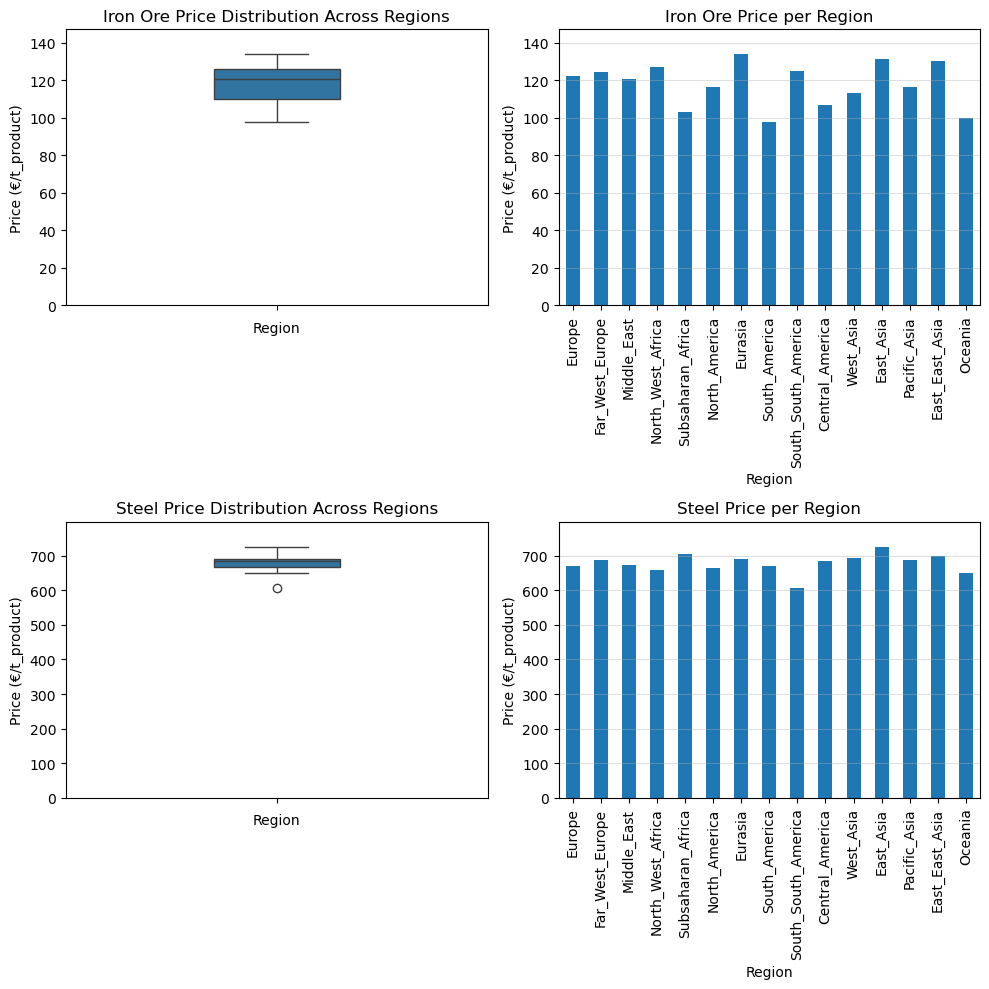

In [163]:
# Helper to clean region names (remove _ore)
def clean_region_names(index):
    return [re.sub(r'_ore$', '', str(i)) for i in index]

# Prepare data for both carriers
data = {
    'iron_ore': iron_ore_price,
    'steel': steel_price
}
titles = {
    'iron_ore': 'Iron Ore',
    'steel': 'Steel'
}

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for i, (carrier, price_df) in enumerate(data.items()):
    # Clean region names
    price_df = price_df.copy()
    price_df.columns = clean_region_names(price_df.columns)
    price_T = price_df.T
    price_T.columns = ['Price']
    price_T.index = clean_region_names(price_T.index)

    # Boxplot (narrower)
    sns.boxplot(data=price_df.melt(var_name='Region', value_name=""), ax=axes[i,0], width=0.3)
    axes[i,0].set_title(f'{titles[carrier]} Price Distribution Across Regions')
    axes[i,0].set_ylabel('Price (€/t_product)')
    axes[i,0].set_xlabel('Region')
    axes[i,0].set_ylim(0, price_df.max().max() * 1.1)

    # Bar plot
    price_T.plot(kind='bar', ax=axes[i,1], legend=False, width=0.5)
    axes[i,1].set_title(f'{titles[carrier]} Price per Region')
    axes[i,1].set_ylabel('Price (€/t_product)')
    axes[i,1].set_xlabel('Region')
    axes[i,1].set_xticklabels(price_T.index, rotation=90)
    axes[i,1].set_ylim(0, price_df.max().max() * 1.1)
    axes[i,1].grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

### Cost and prices

Thesis: The price of steel equals the cost of a single region + transport costs of iron ore and steel. The cost of a single region benchmark depends to what degree the steel making potential in the respective region is used ("marginal"). Hence, if all potentials are used, even the most expensive ones, then this is the benchmark.

steel price = steel production (region, marginal) + transport iron ore + transport steel